O objetivo desse experimento é reproduzir os resultados do paper:

RASHT-BEHESHT, Majid; HUBER, Christian; SHUKLA, Khemraj; KARNIADAKIS, George Em. \
**Physics-informed neural networks (PINNs) for wave propagation and full waveform inversions**. \
*Journal of Geophysical Research: Solid Earth*, v. 127, n. 5, e2021JB023120, 2022. DOI: 10.1029/2021JB023120.

### Importando bibliotecas

In [3]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
%matplotlib inline
from pathlib import Path
import sys

import scipy.interpolate as interpolate

sys.path.append(os.path.abspath('/mnt/storage_C4/leticia_aleixo/piml-pub/proj-01/utils'))
from specfem_loader import SpecfemDataLoader

In [4]:
# Device Configuration: use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [5]:
RANDOM_STATE = 42

### Definindo a geometria de aquisição

Definindo:
- x: eixo horizontal
- z: eixo vertical

O domínio físico:

In [6]:
# definindo o domínio físico

nx = 100
nz = 100

ax_spec = 1.5 # km
az_spec = 0.5 # km

n_abs = 10 # numero de camadas absorventes para evitar que as ondas reflitam
n_absx = n_abs
n_absz = n_abs

# fatores de discretização:
dx = ax_spec / nx # 0.015 km espaçamento da malha no eixo x
dz = az_spec / nz # 0.005 km espaçamento da malha no eixo z

# posição da linha de receptores
xsf = 1.3 # km
# a profundidade varia

# domínio utilizado pela PINN
ax = xsf - n_absx * dx # a camada absorvente é removida e redefinimo o domínio da pinn
az = az_spec - n_absz * dz # novo domínio vertical da pinn

Definições para o tempo

In [7]:
# tempo:
s_spec = 5e-5 # passo temporal do specfem em segundos

t_st = 0.10 # tempo inicial do treinamento
t_m = 0.50 # tempo final do treinamento
t_s = 0.50 # comprimento dos seismogramas

t01 = 2000 * s_spec # primeiro snapshot
t02 = 2300 * s_spec # segundo snapshot
t_la = 5000 * s_spec # snapshot para validação

Escalas de normalização:

In [8]:
# escalas de normalização:
Lx = 3.0 # "this is for scaling the wavespeed in the PDE via scaling x coordinate"
Lz = 3.0 # 'this is for scaling the wavespeed in the PDE via scaling z coordinate'

u_scl = 1 / 3640

Definindo a geometria de aquisição:

In [9]:
# geometria de aquisição:
n_event = 1
n_recept = 20

# linha de receptores 
x_receiver = 1.3 # km 
z0_s = az # localização do primeiro sismometro
zl_s = 0.06 - n_abs * dz # localização do último sismometro

d_s = abs(zl_s - z0_s) / (n_recept - 1) # espaçamento dos receptores

In [10]:
print(f"Domínio PINN: {ax:.3f} km × {az:.3f} km")
print(f"dx = {dx:.3f} km")
print(f"dz = {dz:.3f} km")
print(f"{n_recept} receptores")

Domínio PINN: 1.150 km × 0.450 km
dx = 0.015 km
dz = 0.005 km
20 receptores


**Traços sísmicos:**

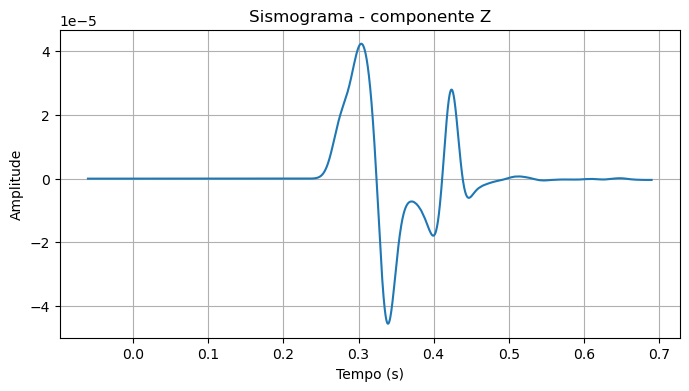

In [11]:
# idx do sismograma
idx = '01' # 01 a 20

plt.figure(figsize=(8,4))

trace = np.loadtxt(
    f"/mnt/storage_C4/leticia_aleixo/piml-pub/rasht-behesht_etal_2021/event1/seismograms/AA.S00{idx}.BXZ.semd"
)

plt.plot(trace[:,0], trace[:,1])

plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.title("Sismograma - componente Z")
plt.grid(True)
plt.show()

### Campo de onda

In [12]:
BASE = Path("/mnt/storage_C4/leticia_aleixo/piml-pub/rasht-behesht_etal_2021")

EVENT = BASE / "event1"

SEISM_DIR = EVENT / "seismograms"
WAVEFIELD_DIR = EVENT / "wavefields"

In [13]:
wavefield_files = sorted(os.listdir(WAVEFIELD_DIR))
seismogram_files = sorted(os.listdir(SEISM_DIR))

In [14]:
wavefields = []
seismograms = []
for file in wavefield_files:
    wavefield = np.loadtxt(WAVEFIELD_DIR / file)
    wavefields.append(wavefield)

for file in seismogram_files:
    seismogram = np.loadtxt(SEISM_DIR / file)
    seismograms.append(seismogram)

Visualiando os campos de onda

In [15]:
import numpy as np

n_wf = len(wavefield_files) -1 # número de amostras do campo de onda
grid = np.loadtxt(WAVEFIELD_DIR / "wavefield_grid_for_dumps_000.txt")

U = np.loadtxt(WAVEFIELD_DIR / wavefield_files[0]) # campo de onda {0, 1, 2}
print(U.shape)

(160801, 2)


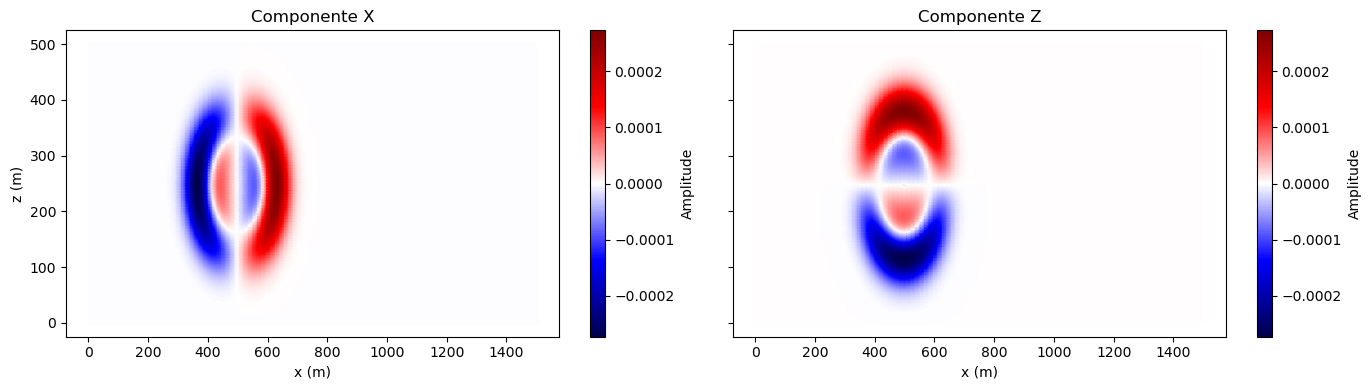

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True, sharey=True)

sc1 = axes[0].scatter(grid[:, 0], grid[:, 1], c=U[:, 0], s=4, cmap="seismic")

axes[0].invert_yaxis()
axes[0].set_title("Componente X")
axes[0].set_xlabel("x (m)")
axes[0].set_ylabel("z (m)")
fig.colorbar(sc1, ax=axes[0], label="Amplitude")

sc2 = axes[1].scatter(grid[:, 0], grid[:, 1], c=U[:, 1], s=4, cmap="seismic")

axes[1].invert_yaxis()
axes[1].set_title("Componente Z")
axes[1].set_xlabel("x (m)")
fig.colorbar(sc2, ax=axes[1], label="Amplitude")

plt.tight_layout()
plt.show()

### Reprodução do paper usando pyTorch

In [17]:
import torch.nn as nn
from torch.optim import Adam

A **inicialização de Xavier** é usada para inicializar pesos que evitem que o sinal fique muito fraco (*vanishing gradient*) ou muito fortes (*exploding gradient*) nas camadas mais profundas.

In [18]:
# inicialização xavier
def xavier_init(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        nn.init.zeros_(m.bias)

A entrada das redes serão normalizadas para [-1, 1] e ao longo do treinamento serão usadas como função de ativação $\sigma = \sin(\cdot)$ ou $\tanh(\cdot)$.
$$
X \rightarrow \frac{2X}{max(X)} -1
$$

In [19]:
LAYERS_PHI = [3, 30, 30, 30, 1]
LAYERS_ALPHA = [2, 50, 50, 50, 50, 50, 1]

In [20]:
# definindo pesos e baises para a rede neural

weights = [xavier_init((LAYERS_PHI[i], LAYERS_PHI[i+1])) for i in range(len(LAYERS_PHI)-1)]
biases = [torch.zeros((1, LAYERS_PHI[i+1]), device=device) for i in range(len(LAYERS_PHI)-1)]

weights0 = [xavier_init((LAYERS_ALPHA[i], LAYERS_ALPHA[i+1])) for i in range(len(LAYERS_ALPHA)-1)]
biases0 = [torch.zeros((1, LAYERS_ALPHA[i+1]), device=device) for i in range(len(LAYERS_ALPHA)-1)]

#### Rede Neural para aprender a função $\phi (x, z, t)$:

In [21]:
class PhiNet(nn.Module):
    '''
    Rede neural para aproximar o potencial escalar ϕ.
    Input:
        Entradas:
            [x, z, t] (normalizada para [-1, 1])
            layers_phi: list com a quantidade de neurônios por layer [N0, N1, ...]
    '''
    def __init__(self, layers_phi=LAYERS_PHI):
        super().__init__()

        # definindo as layers ocultas com função de ativação tanh
        hidden_layers = [
            layer for i in range(len(layers_phi) - 2)
            for layer in (nn.Linear(layers_phi[i], layers_phi[i+1]),
            nn.Tanh())]
        
        output_layer = [nn.Linear(layers_phi[-2], layers_phi[-1])]

        self.net = nn.Sequential(*hidden_layers, *output_layer)
        self.apply(xavier_init)
        
        # limites de normalização: [ax/Lx, az/Lz, t_m-t_st]
        ub = torch.tensor([ax / Lx, az / Lz, t_m - t_st], dtype=torch.float64).to(device)
        self.register_buffer("ub", ub) # armazenando parâmetros não treináveis

    def forward(self, xzt):
        # normalização para [-1, 1]
        x_norm = (2.0 * xzt) / self.ub - 1.0
        return self.net(x_norm)

#### Rede Neural para a velocidade $\alpha (x, z)$:


In [22]:
class AlphaNet(nn.Module):
    """
    Aproxima a velocidade da onda \alpha
    Entrada: [x, z]  (normalizada para [-1, 1])
    Camadas: [2, N1, N2, N3, N4, N5, 1]  (igual ao original)
    Saída confinada a uma caixa via smooth step.
    """
    def __init__(self, layers_alpha=LAYERS_ALPHA):
        super().__init__()

        hidden_layers = [
            layer for i in range(len(layers_alpha) - 2)
            for layer in (nn.Linear(layers_alpha[i], layers_alpha[i+1]),
            nn.Tanh())]

        output_layer = [nn.Linear(layers_alpha[-2], layers_alpha[-1])]

        self.net = nn.Sequential(*hidden_layers, *output_layer)
        self.apply(xavier_init)

        ub0 = torch.tensor([ax / Lx, az / Lz], dtype=torch.float64).to(device)
        self.register_buffer("ub0", ub0)

        # limites da caixa de inversão (mesma região usada no paper: um retângulo
        # ao redor da anomalia de baixa velocidade, referenciado ao domínio do PINN,
        # ou seja, já descontando a camada absorvente do SPECFEM)

        # horizontal (eixo x)
        self.x_st = 0.7 - n_absx * dx
        self.x_fi = 1.25 - n_absx * dx

        # vertical (eixo z)
        self.z_st = 0.10 - n_absz * dz
        self.z_fi = 0.45 - n_absz * dz

        # lld: controla quão abrupta ou suave é a borda da caixa de inversão.
        self.lld = 1000.0

    def _alpha_star(self, xz):
        # normalização para [-1, 1]
        x_n = (2.0 * xz) / self.ub0 - 1.0
        return torch.tanh(self.net(x_n))

    def _box_mask(self, xv, zv):
        """
        Indicador suave (produto de degraus tanh) da caixa de inversão:
        vale ~1 dentro do retângulo [x_st,x_fi] x [z_st,z_fi] e ~0 fora dele.

        NOTA (correção): na versão anterior desta célula os limites de x e z
        estavam trocados entre si (e self.x_st sequer existia -- só
        self.y_st/self.y_fi haviam sido definidos). Aqui os limites em x
        (x_st, x_fi) são aplicados à coordenada xv, e os limites em z
        (z_st, z_fi) à coordenada zv, exatamente como no `alpha_bound`
        do script original em TensorFlow.
        """
        mask = (
            0.5 * (1 + torch.tanh(self.lld * (xv - self.x_st / Lx))) *
            0.5 * (1 + torch.tanh(self.lld * (-xv + self.x_fi / Lx))) *
            0.5 * (1 + torch.tanh(self.lld * (zv - self.z_st / Lz))) *
            0.5 * (1 + torch.tanh(self.lld * (-zv + self.z_fi / Lz)))
        )
        return mask

    def forward(self, xv, zv):
        """
        Retorna \alpha(x, z).
        xv, zv : tensores coluna [N,1] com gradiente habilitado.
        """
        xz = torch.cat([xv, zv], dim=1)
        a_star = self._alpha_star(xz)
        mask = self._box_mask(xv, zv)
        alpha = 3.0 + 2.0 * a_star * mask
        return alpha


**Velocidade verdadeira do modelo**

Será usada como ground truth para comparação durante o treinamento.

In [23]:
def alpha_true_fn(vel_model, xv, zv):
    # velocidade verdadeira para cada coordenada x, z
    return vel_model[xv, zv]

Definir malha de pontos para avaliação $K \times K$. 

O objetivo é poder usar posteriormente para fazer avaliações pontuais do resultado do modelo:

In [ ]:
n_ini = 40  # resolução da malha para as condições iniciais

xx_np, zz_np = np.meshgrid( # malha regular no domínio da PINN
    np.linspace(0, ax / Lx, n_ini), # eixo x (horizontal)
    np.linspace(0, az / Lz, n_ini) # eixo z (vertical)
)

xx0_np = xx_np.reshape(-1, 1)
zz0_np = zz_np.reshape(-1, 1)

# primeira condição inicial:
X_init1 = np.concatenate((xx0_np, zz0_np, 0*np.ones((n_ini**2,1),dtype=np.float64)), axis=1)
# segunda condição inicial:
X_init2 = np.concatenate((xx0_np, zz0_np, (t02 - t01)*np.ones((n_ini**2,1),dtype=np.float64)), axis=1)

def np2t(arr, requires_grad=False):
    """Converte numpy para tensor float64 no device correto."""
    return torch.tensor(arr, dtype=torch.float64, device=device, requires_grad=requires_grad)

**Scalar acoustic wave potential**

### A equação de onda acústica escalar

Seguindo Rasht-Behesht et al. (2021), em vez de aproximar diretamente o campo de
deslocamento $\mathbf{u}(x,z,t) = (u_x, u_z)$, a `PhiNet` aproxima um **potencial
escalar** $\phi(x,z,t)$ tal que:

$$
\mathbf{u} = \nabla \phi \quad\Longrightarrow\quad u_x = \frac{\partial \phi}{\partial x_{km}},\;\; u_z = \frac{\partial \phi}{\partial z_{km}}
$$

Isso é possível porque, em um meio acústico (sem cisalhamento), o campo de
deslocamento é **irrotacional**, logo pode ser escrito como o gradiente de um
potencial. Usar $\phi$ em vez de $(u_x, u_z)$ diretamente tem a seguinte vantagem prática: a equação de onda vetorial vira uma única equação escalar, e $\mathbf{u}$ é obtido via `autograd`, sempre satisfazendo $\nabla \times \mathbf{u} = 0$ por construção.

A **equação de onda acústica escalar** que $\phi$ deve satisfazer é:

$$
\frac{\partial^2 \phi}{\partial t^2} = \alpha(x,z)^2 \left( \frac{\partial^2 \phi}{\partial x^2} + \frac{\partial^2 \phi}{\partial z^2} \right)
$$

onde $\alpha(x,z)$ é a velocidade de propagação da onda P (o campo que queremos inverter com a `AlphaNet`).


As coordenadas de entrada da rede são normalizadas por
$L_x, L_z$ (`x = x_{km}/Lx`, `z = z_{km}/Lz`), então a regra da cadeia introduz um
fator $(1/L_x)^2$ e $(1/L_z)^2$ nas derivadas segundas espaciais:

$$
P(x,z,t) \equiv \left(\frac{1}{L_x}\right)^2 \frac{\partial^2 \phi}{\partial x^2} + \left(\frac{1}{L_z}\right)^2 \frac{\partial^2 \phi}{\partial z^2}
$$

$$
\text{residual da PDE:}\qquad \mathcal{R} = \frac{\partial^2 \phi}{\partial t^2} - \alpha^2 P
$$

O objetivo do treinamento é levar $\mathcal{R} \to 0$ em pontos de colocação
amostrados no domínio espaço-temporal, ao mesmo tempo em que $\phi$ (via $u_x, u_z$)
casa com as condições iniciais e os sismogramas observados.

$P$ também vai ser reaproveitado adiante: no topo do domínio (superfície livre),
impomos $P \approx 0$ como uma condição de contorno aproximada de tensão nula.

In [ ]:
torch.set_default_dtype(torch.float64)

# instanciando as duas redes: phi_net aprende o potencial de onda, alpha_net aprende (inverte) o campo de velocidade
phi_net = PhiNet(LAYERS_PHI).to(device)
alpha_net = AlphaNet(LAYERS_ALPHA).to(device)

print(phi_net)
print(alpha_net)

PhiNet(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=30, bias=True)
    (1): Tanh()
    (2): Linear(in_features=30, out_features=30, bias=True)
    (3): Tanh()
    (4): Linear(in_features=30, out_features=30, bias=True)
    (5): Tanh()
    (6): Linear(in_features=30, out_features=1, bias=True)
  )
)
AlphaNet(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=50, bias=True)
    (1): Tanh()
    (2): Linear(in_features=50, out_features=50, bias=True)
    (3): Tanh()
    (4): Linear(in_features=50, out_features=50, bias=True)
    (5): Tanh()
    (6): Linear(in_features=50, out_features=50, bias=True)
    (7): Tanh()
    (8): Linear(in_features=50, out_features=50, bias=True)
    (9): Tanh()
    (10): Linear(in_features=50, out_features=1, bias=True)
  )
)


### Carregando os dados do SPECFEM com o `SpecfemDataLoader`

Até aqui os dados do SPECFEM foram lidos para
inspeção. Daqui em diante usamos o `SpecfemDataLoader`, que faz todo o
pré-processamento:

- leitura dos wavefields e sismogramas de cada evento;
- interpolação dos wavefields da malha nativa do SPECFEM para a malha do PINN
  (`griddata`), já descontando a camada absorvente (PML);
- montagem das condições iniciais `X_init1`/`X_init2` (snapshots em $t_{01}$ e $t_{02}$);
- corte e subamostragem temporal dos sismogramas na janela de treino $[t_{st}, t_s]$;
- montagem das coordenadas espaço-temporais dos receptores `X_S`.

Os parâmetros passados são exatamente os mesmos já definidos nas células de
configuração da geometria/tempo acima.

In [26]:
loader = SpecfemDataLoader(
    Lx=Lx, Lz=Lz,
    dx=dx, dz=dz,
    n_absx=n_absx, n_absz=n_absz,
    xsf=xsf, az_spec=az_spec,
    n_ini=n_ini,
    t_st=t_st, t_s=t_s,
    t01=t01, t02=t02, t_la=t_la,
    n_event=n_event,
    n_seis=n_recept,
    u_scl=u_scl,
    zl_s=zl_s, z0_s=z0_s,
    root_dir=str(BASE),
)

data = loader.load()

# checagem rápida: forma de cada array retornado
for k, v in data.items():
    print(f"{k:8s} -> {getattr(v, 'shape', v)}")

X_init1  -> (1600, 3)
X_init2  -> (1600, 3)
X_S      -> (1620, 3)
Ui1x     -> (1600, 1)
Ui1z     -> (1600, 1)
Ui2x     -> (1600, 1)
Ui2z     -> (1600, 1)
Usx      -> (1600, 1)
Usz      -> (1600, 1)
Sz       -> (1620, 1)
Sx       -> (1620, 1)
l_sub    -> 81
d_s      -> ()
xxzzs    -> (1600, 2)
xxs      -> (40, 40)
zzs      -> (40, 40)
xx       -> (40, 40)
zz       -> (40, 40)


**O que cada chave de `data` representa:**

| chave | significado |
|---|---|
| `X_init1`, `X_init2` | coordenadas `(x, z, t)` das duas condições iniciais (snapshots em $t_{01}$, $t_{02}$) |
| `Ui1x`, `Ui1z` | deslocamento (x, z) do SPECFEM em $t_{01}$, interpolado na grade do PINN — alvo de `loss_init_disp1` |
| `Ui2x`, `Ui2z` | idem, em $t_{02}$ — alvo de `loss_init_disp2` |
| `Usx`, `Usz` | snapshot em $t_{la}$, usado só como referência de teste/visualização (não entra na loss) |
| `X_S` | coordenadas `(x, z, t)` de cada amostra de sismograma (dado observado) |
| `Sz`, `Sx` | sismogramas observados (componentes Z e X) — alvo de `loss_seism` |
| `l_sub` | nº de amostras temporais por receptor, após subamostragem |
| `d_s` | espaçamento entre receptores |
| `xx`, `zz` | grade `(x,z)` local da PINN (referencial que começa em 0) |
| `xxs`, `zzs`, `xxzzs` | a mesma grade, no referencial do SPECFEM (usada só internamente p/ interpolação) |

In [ ]:
'''
convertendo tudo para tensores torch (float64, no device correto).
X_init1/X_init2/X_S entram na rede -> precisam de requires_grad=True
(o autograd vai derivar phi em relação a x,z,t para montar a PDE e as
condições iniciais). Os alvos (Ui1x, Sz, ...) são apenas constantes de
comparação na loss -> requires_grad=False.
'''

X_init1_t = np2t(data["X_init1"], requires_grad=True)
X_init2_t = np2t(data["X_init2"], requires_grad=True)
X_S_t     = np2t(data["X_S"],     requires_grad=True)

Ui1x_t, Ui1z_t = np2t(data["Ui1x"]), np2t(data["Ui1z"])
Ui2x_t, Ui2z_t = np2t(data["Ui2x"]), np2t(data["Ui2z"])
Usx_t,  Usz_t  = np2t(data["Usx"]),  np2t(data["Usz"])

Sz_t = np2t(data["Sz"])
Sx_t = np2t(data["Sx"])

d_s = data["d_s"]
l_sub = data["l_sub"]

print("X_init1:", X_init1_t.shape, " X_init2:", X_init2_t.shape, " X_S:", X_S_t.shape)
print("Sz:", Sz_t.shape, " Sx:", Sx_t.shape)

X_init1: torch.Size([1600, 3])  X_init2: torch.Size([1600, 3])  X_S: torch.Size([1620, 3])
Sz: torch.Size([1620, 1])  Sx: torch.Size([1620, 1])


### Pontos de colocação para o resíduo da PDE

A PDE não é imposta em toda parte do domínio contínuo, e sim em um
conjunto finito de pontos $(x,z,t)$ amostrados dentro do domínio de treino
$[0, a_x/L_x] \times [0, a_z/L_z] \times [0, t_m - t_{st}]$, os **pontos de colocação**.

Usamos uma sequência de Sobol em vez de
amostragem puramente aleatória, porque sequências de baixa discrepância cobrem o
espaço de forma mais uniforme que pontos i.i.d., o que ajuda o treino do PINN a
"ver" a PDE de forma mais homogênea pelo domínio.

In [ ]:
from torch.quasirandom import SobolEngine

BATCH_SIZE_PDE = batch_size = 40000 # número de pontos de PDE por passo de otimização
N_PDE_BATCHES = 2000 # número de minibatches pré-amostrados

n_pde = BATCH_SIZE_PDE * N_PDE_BATCHES

sobol = SobolEngine(dimension=3, scramble=True, seed=RANDOM_STATE)
X_pde_np = sobol.draw(n_pde).numpy()

X_pde_np[:, 0] *= ax / Lx
X_pde_np[:, 1] *= az / Lz
X_pde_np[:, 2] *= (t_m - t_st)

print("X_pde:", X_pde_np.shape)

X_pde: (80000000, 3)


### Condição de contorno: superfície livre

No topo do domínio ($z = a_z/L_z$) impomos uma condição de **superfície livre**
(tensão normal nula). Em termos do potencial escalar, isso é aproximado impondo
$P(x, z{=}a_z/L_z, t) \approx 0$, o mesmo $P$ (Laplaciano ponderado por $1/L_x^2,
1/L_z^2$) usado no resíduo da PDE. 

A cada 200 épocas, um novo conjunto de pontos de contorno (aleatórios em $x$ e
$t$, fixos em $z = a_z/L_z$) é reamostrado, assim como o minibatch de PDE.

In [29]:
def sample_bc_points(bcxn=100, bctn=50, rng=None):
    """Amostra pontos (x, z=az/Lz, t) na superfície livre (topo do domínio)."""
    rng = rng or np.random
    x_vec = rng.rand(bcxn, 1) * ax / Lx
    t_vec = rng.rand(bctn, 1) * (t_m - t_st)
    xxb, ttb = np.meshgrid(x_vec, t_vec)
    X_BC = np.concatenate(
        (xxb.reshape((-1, 1)),
         az / Lz * np.ones((xxb.size, 1)),
         ttb.reshape((-1, 1))),
        axis=1,
    )
    return X_BC

X_BC_np = sample_bc_points()
print("X_BC:", X_BC_np.shape)

X_BC: (5000, 3)


### Montando o resíduo da PDE

Em vez de discretizar derivadas (diferenças
finitas, elementos finitos, ...), usamos diferenciação automática para obter
derivadas *exatas* de $\phi$ em relação às suas entradas, diretamente do grafo
computacional da rede.

Para um lote de pontos `xzt = [x, z, t]` (com `requires_grad=True`):

1. `phi = phi_net(xzt)`
2. `u_x = ∂phi/∂x`, `u_z = ∂phi/∂z`  →  deslocamento (definição $\mathbf{u} = \nabla\phi$)
3. `phi_xx = ∂u_x/∂x`, `phi_zz = ∂u_z/∂z`  → derivadas segundas espaciais
4. `phi_tt = ∂²phi/∂t²`  → aceleração do potencial
5. `alpha = alpha_net(x, z)`  → velocidade estimada naquele ponto
6. resíduo: `eq = phi_tt − alpha² · P`, com `P = (1/Lx)² phi_xx + (1/Lz)² phi_zz`


In [ ]:
def grad(outputs, inputs):
    """Atalho para obter d(outputs)/d(inputs), mantendo o grafo para derivar de novo."""
    return torch.autograd.grad(outputs, inputs, grad_outputs=torch.ones_like(outputs), create_graph=True, retain_graph=True,)[0]


def pde_residual(phi_net, alpha_net, xzt):
    """
    Calcula, para um lote de pontos xzt = [x, z, t] (requires_grad=True):
      - eq       : resíduo da equação de onda, phi_tt - alpha^2 * P
      - ux, uz   : campo de deslocamento (gradiente do potencial)
      - vel_x, vel_z : campo de velocidade (derivada temporal do deslocamento)
      - alpha    : velocidade estimada em cada ponto
      - P        : laplaciano ponderado (reutilizado na loss de contorno)
    """
    x, z, t = xzt[:, 0:1], xzt[:, 1:2], xzt[:, 2:3]
    xzt_in = torch.cat([x, z, t], dim=1)

    phi = phi_net(xzt_in)

    ux = grad(phi, x)
    uz = grad(phi, z)

    phi_xx = grad(ux, x)
    phi_zz = grad(uz, z)
    P = (1.0 / Lx) ** 2 * phi_xx + (1.0 / Lz) ** 2 * phi_zz

    phi_t = grad(phi, t)
    phi_tt = grad(phi_t, t)

    vel_x = grad(ux, t)
    vel_z = grad(uz, t)

    alpha = alpha_net(x, z)

    eq = phi_tt - alpha ** 2 * P

    return {
        "eq": eq, "ux": ux, "uz": uz,
        "vel_x": vel_x, "vel_z": vel_z,
        "alpha": alpha, "P": P,
    }

### Função de perda: física + dados

A loss combina cinco termos, cada um cobrando de $\phi$ (e indiretamente de
$\alpha$) um comportamento físico diferente:

$$
\mathcal{L} = \underbrace{\lambda_{pde}\,\mathcal{L}_{pde}}_{\text{obedece a eq. de onda}}
+ \underbrace{\mathcal{L}_{ini,1} + \mathcal{L}_{ini,2}}_{\text{respeita os 2 snapshots do SPECFEM}}
+ \underbrace{\mathcal{L}_{seis}}_{\text{respeita os sismogramas observados}}
+ \underbrace{\lambda_{bc}\,\mathcal{L}_{bc}}_{\text{superfície livre}}
$$

- $\mathcal{L}_{pde} = \text{mean}(\text{eq}^2)$ nos pontos de colocação, obriga $\phi,\alpha$
  a satisfazerem a equação de onda no interior do domínio;
- $\mathcal{L}_{ini,1}, \mathcal{L}_{ini,2}$: erro quadrático entre $(u_x,u_z)$ previstos e os
  dois snapshots do SPECFEM ($t_{01}$, $t_{02}$). É essencialmente a condição inicial
  do problema (posição + "velocidade" aproximada por dois instantes próximos);
- $\mathcal{L}_{seis}$ (erro quadrático entre $(u_x,u_z)$ previstos nos receptores e os
  sismogramas observados) é o termo de **inversão**: força $\alpha(x,z)$ a se ajustar
  para que a onda simulada pelo PINN se assemelhe aos dados reais;
- $\mathcal{L}_{bc} = \text{mean}(P^2)$ no topo, superfície livre;

In [ ]:
LAMBDA_PDE = 1e-1
LAMBDA_BC = 1e-1


def compute_losses(X_pde_t):
    """
    Recebe o minibatch de pontos de colocação da PDE (já como tensor,
    requires_grad=True) e retorna todas as losses + o total ponderado.
    """
    # resíduo da PDE, no interior do domínio 
    out_pde = pde_residual(phi_net, alpha_net, X_pde_t)
    loss_pde = torch.mean(out_pde["eq"] ** 2)

    # condições iniciais (dois snapshots do SPECFEM)
    out_i1 = pde_residual(phi_net, alpha_net, X_init1_t)
    loss_init_disp1 = torch.mean((out_i1["ux"] - Ui1x_t) ** 2) + torch.mean((out_i1["uz"] - Ui1z_t) ** 2)

    out_i2 = pde_residual(phi_net, alpha_net, X_init2_t)
    loss_init_disp2 = torch.mean((out_i2["ux"] - Ui2x_t) ** 2) + torch.mean((out_i2["uz"] - Ui2z_t) ** 2)

    # dado observado: sismogramas
    out_s = pde_residual(phi_net, alpha_net, X_S_t)
    loss_seism = torch.mean((out_s["ux"] - Sx_t) ** 2) + torch.mean((out_s["uz"] - Sz_t) ** 2)

    # contorno: superfície livre (P ≈ 0 no topo)
    X_BC_t = np2t(sample_bc_points(), requires_grad=True)
    out_bc = pde_residual(phi_net, alpha_net, X_BC_t)
    loss_bc = torch.mean(out_bc["P"] ** 2)

    total = (LAMBDA_PDE * loss_pde
             + loss_init_disp1 + loss_init_disp2
             + loss_seism
             + LAMBDA_BC * loss_bc)

    return {
        "total": total,
        "pde": loss_pde,
        "init1": loss_init_disp1,
        "init2": loss_init_disp2,
        "seism": loss_seism,
        "bc": loss_bc,
    }

### Loop de treinamento

1. otimizador Adam único, atualizando **as duas redes** simultaneamente
   (`phi_net` aprende a propagar a onda, `alpha_net` aprende a velocidade,
   ambas são treinadas ao mesmo tempo, guiadas pela mesma loss);
2. a cada época, um passo de gradiente sobre o minibatch de PDE atual;
3. a cada `LOG_EVERY` épocas: (a) registra as losses, (b) sorteia um **novo**
   minibatch de PDE (avançando pelos `N_PDE_BATCHES` pré-amostrados) e um novo
   conjunto de pontos de contorno, (c) salva os pesos em disco.

In [ ]:
import time

NUM_EPOCHS = 200000
LEARNING_RATE = 1e-4
LOG_EVERY = 200
CHECKPOINT_PATH = "recorded_weights_2e5_epochs.pt"

optimizer = Adam(
    list(phi_net.parameters()) + list(alpha_net.parameters()),
    lr=LEARNING_RATE,
)

loss_rec = np.empty((0, 6))  # epoch, total, pde, init1, init2, seism (bc fica de fora só p/ manter shape do original)
bbn = 0  # índice do minibatch de PDE atual

In [33]:
start = time.time()

for epoch in range(NUM_EPOCHS):
    X_pde_batch = X_pde_np[bbn * BATCH_SIZE_PDE:(bbn + 1) * BATCH_SIZE_PDE]
    X_pde_t = np2t(X_pde_batch, requires_grad=True)

    optimizer.zero_grad()
    losses = compute_losses(X_pde_t)
    losses["total"].backward()
    optimizer.step()

    if epoch % LOG_EVERY == 0:
        elapsed = time.time() - start
        print(
            f"Epoch {epoch:7d} | Time {elapsed:8.1f}s | "
            f"Loss {losses['total'].item():.4e} | "
            f"PDE {losses['pde'].item():.4e} | "
            f"Init1 {losses['init1'].item():.4e} | "
            f"Init2 {losses['init2'].item():.4e} | "
            f"Seism {losses['seism'].item():.4e} | "
            f"BC {losses['bc'].item():.4e}"
        )

        loss_rec = np.concatenate((
            loss_rec,
            np.array([[epoch,
                        losses["total"].item(),
                        losses["pde"].item(),
                        losses["init1"].item(),
                        losses["init2"].item(),
                        losses["seism"].item()]]),
        ), axis=0)

        # novo minibatch de PDE para os próximos LOG_EVERY passos
        bbn = (bbn + 1) % N_PDE_BATCHES

        # checkpoint dos pesos + histórico de loss
        torch.save({
            "phi_net": phi_net.state_dict(),
            "alpha_net": alpha_net.state_dict(),
            "loss_rec": loss_rec,
            "epoch": epoch,
        }, CHECKPOINT_PATH)

/home/al.leticia.ferreira/.local/lib/python3.12/site-packages/torch/autograd/graph.py:979: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:408.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch       0 | Time      0.2s | Loss 1.3217e+02 | PDE 6.7788e+02 | Init1 2.2102e+01 | Init2 2.2470e+01 | Seism 1.9268e+01 | BC 5.4332e+00
Epoch     200 | Time     14.3s | Loss 9.7345e-01 | PDE 5.7526e+00 | Init1 1.2423e-01 | Init2 1.1882e-01 | Seism 1.4598e-01 | BC 9.1714e-02
Epoch     400 | Time     28.6s | Loss 4.4303e-01 | PDE 1.6459e+00 | Init1 1.0035e-01 | Init2 9.4101e-02 | Seism 7.6771e-02 | BC 7.2126e-02
Epoch     600 | Time     42.6s | Loss 3.0903e-01 | PDE 9.6337e-01 | Init1 8.4575e-02 | Init2 7.9435e-02 | Seism 4.4256e-02 | BC 4.4267e-02
Epoch     800 | Time     56.5s | Loss 2.4810e-01 | PDE 6.5984e-01 | Init1 7.7842e-02 | Init2 7.3153e-02 | Seism 2.8026e-02 | BC 3.0918e-02
Epoch    1000 | Time     70.5s | Loss 2.1607e-01 | PDE 4.7906e-01 | Init1 7.4954e-02 | Init2 7.0317e-02 | Seism 2.0916e-02 | BC 1.9773e-02
Epoch    1200 | Time     84.4s | Loss 1.9811e-01 | PDE 3.5807e-01 | Init1 7.3689e-02 | Init2 6.9036e-02 | Seism 1.7890e-02 | BC 1.6899e-02
Epoch    1400 | Time     98

### Avaliação: velocidade invertida, campo de onda e sismogramas

Com as redes treinadas, avaliamos:

1. o campo de velocidade **invertido** $\alpha(x,z)$ (saída da `alpha_net`),
   comparado com a velocidade verdadeira usada para gerar os dados sintéticos
   no SPECFEM;
2. os *snapshots* do campo de deslocamento total $|\mathbf{u}| = \sqrt{u_x^2+u_z^2}$
   previstos pela `phi_net` em $t_{01}$, $t_{02}$ e $t_{la}$, comparados com o
   snapshot de referência do SPECFEM em $t_{la}$ (`Usx`, `Usz` não usado na loss,
   serve só de validação);
3. os sismogramas previstos vs. observados em um receptor específico;
4. a curva de convergência de cada termo da loss.

In [34]:
def eval_grid_points(t_value):
    """Monta pontos (x,z,t=t_value) na grade xx,zz para avaliação."""
    xx0 = data["xx"].reshape((-1, 1))
    zz0 = data["zz"].reshape((-1, 1))
    tt0 = t_value * np.ones_like(xx0)
    X_eval = np.concatenate((xx0, zz0, tt0), axis=1)
    return np2t(X_eval, requires_grad=True)


phi_net.eval()
alpha_net.eval()

X_eval01 = eval_grid_points(0.0)
X_eval02 = eval_grid_points(t02 - t01)
X_evalt  = eval_grid_points(t_la - t01)

out01 = pde_residual(phi_net, alpha_net, X_eval01)
out02 = pde_residual(phi_net, alpha_net, X_eval02)
outt  = pde_residual(phi_net, alpha_net, X_evalt)

xx_shape = data["xx"].shape

U_PINN01 = torch.sqrt(out01["ux"] ** 2 + out01["uz"] ** 2).detach().cpu().numpy().reshape(xx_shape)
U_PINN02 = torch.sqrt(out02["ux"] ** 2 + out02["uz"] ** 2).detach().cpu().numpy().reshape(xx_shape)
U_PINNt  = torch.sqrt(outt["ux"] ** 2 + outt["uz"] ** 2).detach().cpu().numpy().reshape(xx_shape)

U_spec_t = np.sqrt(data["Usx"] ** 2 + data["Usz"] ** 2).reshape(xx_shape)
U_diff = U_spec_t - U_PINNt

alpha_pinn = out01["alpha"].detach().cpu().numpy().reshape(xx_shape)

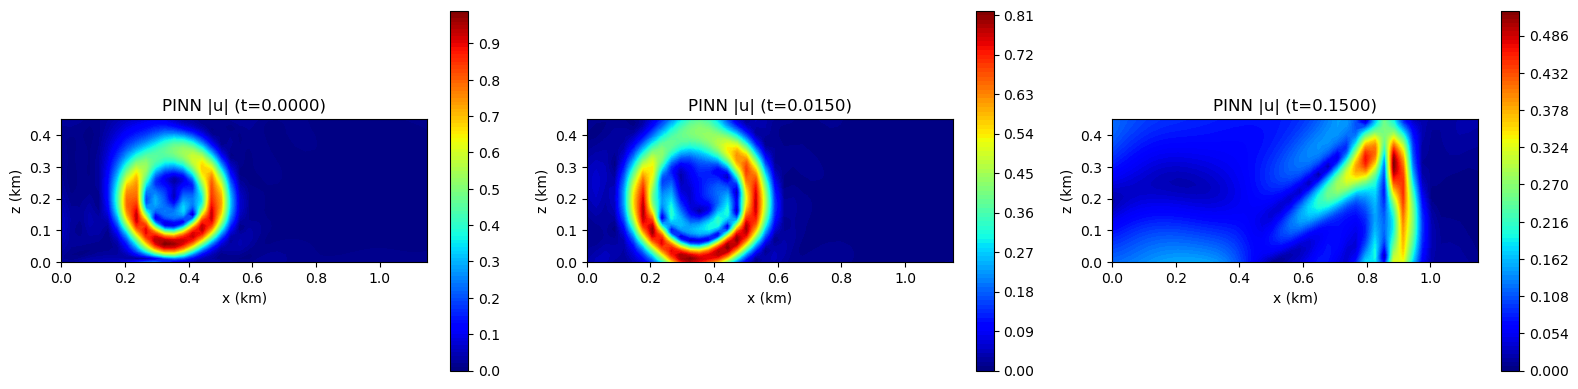

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax_, U, title in zip(
    axes,
    [U_PINN01, U_PINN02, U_PINNt],
    [f"t={0:.4f}", f"t={t02 - t01:.4f}", f"t={t_la - t01:.4f}"],
):
    cf = ax_.contourf(data["xx"] * Lx, data["zz"] * Lz, U, 100, cmap="jet")
    ax_.set_xlabel("x (km)")
    ax_.set_ylabel("z (km)")
    ax_.set_title(f"PINN |u| ({title})")
    ax_.axis("scaled")
    fig.colorbar(cf, ax=ax_)

plt.tight_layout()
plt.savefig("Total_Predicted_dispfield.png", dpi=200)
plt.show()

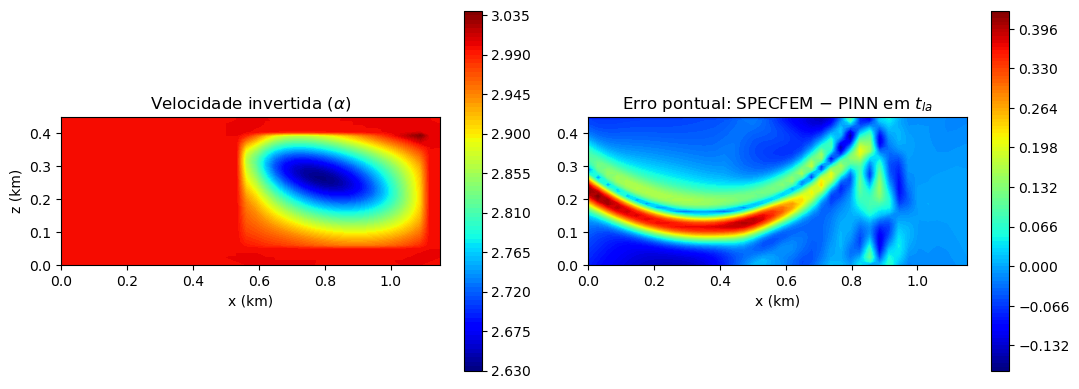

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

cf0 = axes[0].contourf(data["xx"] * Lx, data["zz"] * Lz, alpha_pinn, 100, cmap="jet")
axes[0].set_title(r"Velocidade invertida ($\alpha$)")
axes[0].set_xlabel("x (km)")
axes[0].set_ylabel("z (km)")
axes[0].axis("scaled")
fig.colorbar(cf0, ax=axes[0])

cf1 = axes[1].contourf(data["xx"] * Lx, data["zz"] * Lz, U_diff, 100, cmap="jet")
axes[1].set_title(r"Erro pontual: SPECFEM $-$ PINN em $t_{la}$")
axes[1].set_xlabel("x (km)")
axes[1].axis("scaled")
fig.colorbar(cf1, ax=axes[1])

plt.tight_layout()
plt.savefig("inverted_alpha_and_error.png", dpi=200)
plt.show()

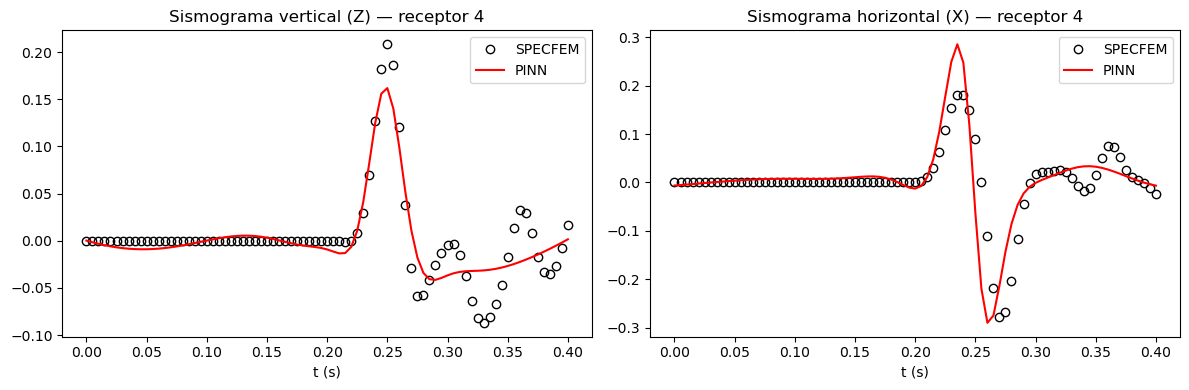

In [40]:
# comparando o sismograma previsto vs. observado em um receptor específico
receiver_idx = 4  # troque para ver outro receptor (0 = mais raso)
sl = slice(receiver_idx * l_sub, (receiver_idx + 1) * l_sub)

out_seism = pde_residual(phi_net, alpha_net, X_S_t)
uz_pred = out_seism["uz"].detach().cpu().numpy()
ux_pred = out_seism["ux"].detach().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(data["X_S"][sl, 2], data["Sz"][sl], "ok", mfc="none", label="SPECFEM")
axes[0].plot(data["X_S"][sl, 2], uz_pred[sl], "r", label="PINN")
axes[0].set_title(f"Sismograma vertical (Z) — receptor {receiver_idx}")
axes[0].set_xlabel("t (s)")
axes[0].legend()

axes[1].plot(data["X_S"][sl, 2], data["Sx"][sl], "ok", mfc="none", label="SPECFEM")
axes[1].plot(data["X_S"][sl, 2], ux_pred[sl], "r", label="PINN")
axes[1].set_title(f"Sismograma horizontal (X) — receptor {receiver_idx}")
axes[1].set_xlabel("t (s)")
axes[1].legend()

plt.tight_layout()
plt.savefig("seismograms_compare.png", dpi=200)
plt.show()

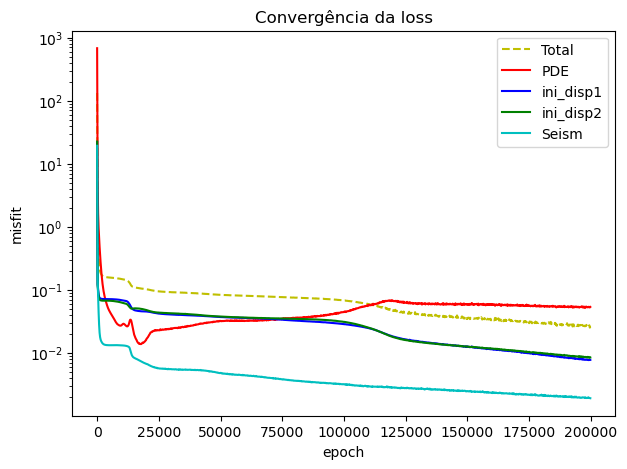

In [38]:
fig = plt.figure(figsize=(7, 5))
plt.plot(loss_rec[:, 0], loss_rec[:, 1], "--y", label="Total")
plt.plot(loss_rec[:, 0], loss_rec[:, 2], "r", label="PDE")
plt.plot(loss_rec[:, 0], loss_rec[:, 3], "b", label="ini_disp1")
plt.plot(loss_rec[:, 0], loss_rec[:, 4], "g", label="ini_disp2")
plt.plot(loss_rec[:, 0], loss_rec[:, 5], "c", label="Seism")
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("misfit")
plt.legend()
plt.title("Convergência da loss")
plt.savefig("misfit.png", dpi=200)
plt.show()